In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

📂 Scanning 622 label files in /home/genki/GR/Sign-Segmentation/processed_data/BIO_tags...

📊 DATASET SIGN DISTRIBUTION
Total Files Analyzed : 622
Files WITH Signs     : 574
Files WITHOUT Signs  : 48 (Only 'Outside' frames)


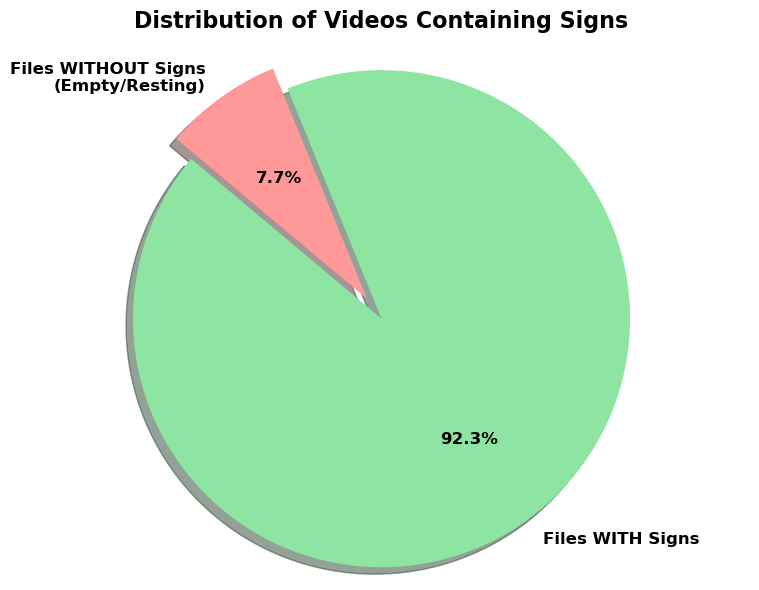

In [2]:
def count_and_plot_empty_signs():
    # Define the target directory
    project_root = Path.cwd()
    
    # Simple check to find the processed_data directory
    for candidate in [project_root, project_root.parent]:
        labels_dir = candidate / "processed_data" / "BIO_tags"
        if labels_dir.exists():
            break
            
    if not labels_dir.exists():
        print(f"❌ Error: Could not find directory {labels_dir}")
        return

    files = list(labels_dir.glob("*.npy"))
    if not files:
        print(f"❌ Error: No .npy files found in {labels_dir}")
        return
        
    print(f"📂 Scanning {len(files)} label files in {labels_dir}...")

    with_signs_count = 0
    without_signs_count = 0
    
    for file_path in files:
        # Load the label array
        labels = np.load(file_path)
        
        # Convert soft labels (T, 3) to hard labels (T,) if necessary
        if labels.ndim > 1:
            hard_labels = np.argmax(labels, axis=1)
        else:
            hard_labels = labels
            
        # BIO classes: 0 = Outside, 1 = Inside, 2 = Begin
        # If the maximum value in the array is 0, there are no signs (no 1s or 2s)
        if np.max(hard_labels) == 0:
            without_signs_count += 1
        else:
            with_signs_count += 1

    # --- Print Summary ---
    print("\n" + "="*40)
    print("📊 DATASET SIGN DISTRIBUTION")
    print("="*40)
    print(f"Total Files Analyzed : {len(files):,}")
    print(f"Files WITH Signs     : {with_signs_count:,}")
    print(f"Files WITHOUT Signs  : {without_signs_count:,} (Only 'Outside' frames)")
    print("="*40)

    # --- Plot Pie Chart ---
    labels = ['Files WITH Signs', 'Files WITHOUT Signs\n(Empty/Resting)']
    sizes = [with_signs_count, without_signs_count]
    colors = ['#8de5a1', '#ff9999'] # Soft green and red
    
    # 'Explode' the empty signs slice slightly to make it stand out
    explode = (0, 0.1) if without_signs_count > 0 else (0, 0)

    plt.figure(figsize=(8, 6))
    plt.pie(sizes, 
            explode=explode, 
            labels=labels, 
            colors=colors, 
            autopct='%1.1f%%',
            shadow=True, 
            startangle=140,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
            
    plt.title('Distribution of Videos Containing Signs', fontsize=16, fontweight='bold', pad=20)
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    count_and_plot_empty_signs()

Using labels directory: /home/genki/GR/Sign-Segmentation/processed_data/BIO_tags
Scanning 622 files to calculate gloss counts...

📊 GLOSS COUNT STATISTICS (Per Video)
Total Videos Analyzed : 622
Total Glosses Found   : 316,410
Average (Mean) Count  : 508.70 glosses
Median Count          : 387.00 glosses
Max Glosses in 1 video: 4082 glosses
Videos with 0 glosses : 48 videos


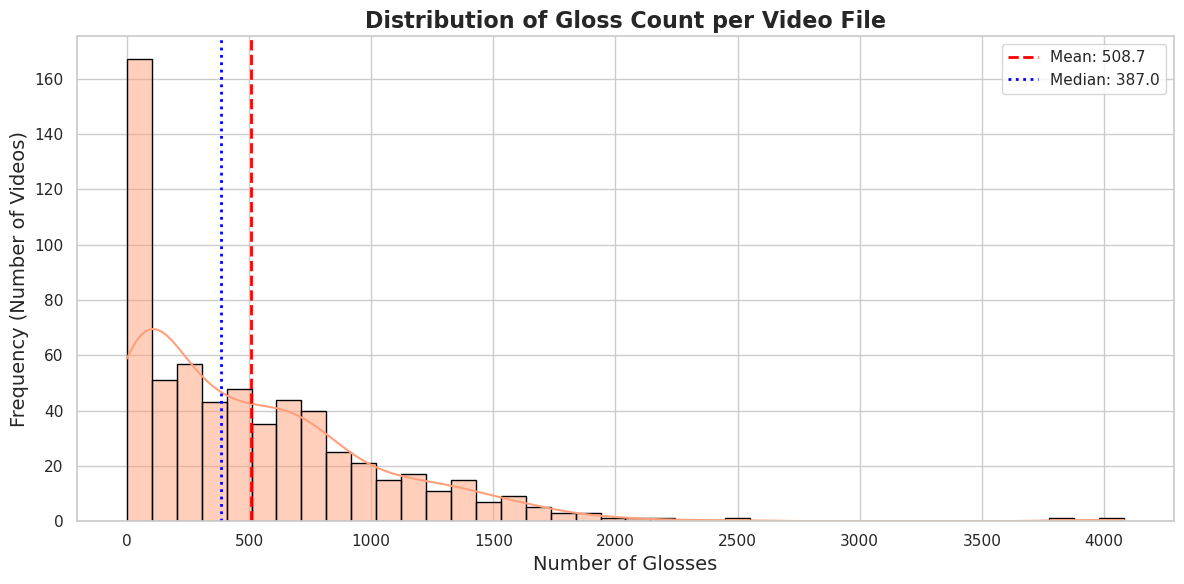

In [ ]:
# ==========================================
# Configuration & Setup
# ==========================================
project_root = Path.cwd()
for candidate in [project_root, project_root.parent]:
    labels_dir = candidate / "processed_data" / "BIO_tags"
    if labels_dir.exists():
        break

if not labels_dir.exists():
    print(f"❌ Error: Could not find directory {labels_dir}")
else:
    print(f"Using labels directory: {labels_dir}")
    
    files = [f for f in os.listdir(labels_dir) if f.endswith('.npy')]
    gloss_counts = []
    
    print(f"Scanning {len(files)} files to calculate gloss counts...")
    
    for file_name in files:
        label_path = os.path.join(labels_dir, file_name)
        labels = np.load(label_path)
        
        # Handle soft labels if present
        if labels.ndim > 1:
            hard_labels = np.argmax(labels, axis=1)
        else:
            hard_labels = labels
            
        # A gloss is defined by the presence of a 'Begin' tag (Class 2)
        # Simply count the number of 2s in the array
        num_glosses = np.sum(hard_labels == 2)
        gloss_counts.append(num_glosses)
    
    # Convert to Pandas Series for easy stats and plotting
    counts_series = pd.Series(gloss_counts)
    
    # --- Print Summary Statistics ---
    print("\n" + "="*40)
    print("📊 GLOSS COUNT STATISTICS (Per Video)")
    print("="*40)
    print(f"Total Videos Analyzed : {len(counts_series):,}")
    print(f"Total Glosses Found   : {counts_series.sum():,}")
    print(f"Average (Mean) Count  : {counts_series.mean():.2f} glosses")
    print(f"Median Count          : {counts_series.median():.2f} glosses")
    print(f"Max Glosses in 1 video: {counts_series.max()} glosses")
    print(f"Videos with 0 glosses : {(counts_series == 0).sum()} videos")
    print("="*40)
    
    # --- Plot the Histogram ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    # Plot histogram with 40 bins as requested
    sns.histplot(counts_series, bins=20, color="#ffa07a", edgecolor="black", kde=True)
    
    plt.title("Distribution of Gloss Count per Video File", fontsize=16, fontweight='bold')
    plt.xlabel("Number of Glosses", fontsize=14)
    plt.ylabel("Frequency (Number of Videos)", fontsize=14)
    
    # Add a vertical line for the mean and median
    plt.axvline(counts_series.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {counts_series.mean():.1f}')
    plt.axvline(counts_series.median(), color='blue', linestyle=':', linewidth=2, label=f'Median: {counts_series.median():.1f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()